**Motivation**

The previous chapter used regression to find the parameters of a function that best estimated a set of data points. Regression assumes that the data set has measurement errors, and that you need to find a set of model parameters that minimize the error between your model and the data. However, sometimes you have measurements that are assumed to be very reliable; in these cases, you want an estimation function that goes through the data points you have. This technique is commonly referred to as interpolation.

**Interpolation Problem Statement**

Assume we have a data set consisting of independent data values, $x_i$, and dependent data values, $y_i$, where $i=1,\dots,n$. We would like to find an estimation function $\widehat{y}(x)$ such that $\widehat{y}(x_i)=y_i$ for every point in our data set. This means the estimation function goes through our data points. Given a new $x^{*}$, we can **interpolate** its function value using $\widehat{y}(x^{*})$. In this context, $\widehat{y}(x)$ is called an interpolation function. The following figure shows the interpolation problem statement.

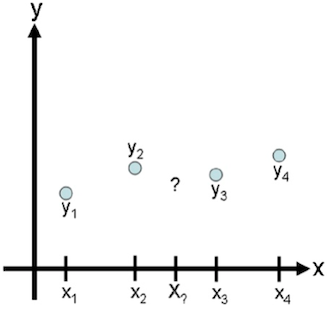

Unlike regression, interpolation does not require the user to have an underlying model for the data, especially when there are many reliable data points. However, the processes that underly the data must still inform the user about the quality of the interpolation.

In the following, we studied several common interpolation methods like Linear, Cubic Spline, Lagrange and Newton's polynomial interpolation.



**Linear Interpolation**

In linear interpolation, the estimated point is assumed to lie on the line joining the nearest points to the left and right. Assume, without loss of generality, that the $x$-data points are in ascending order that is, $x_i<x_{i+1}$, and let $x$ be a point such that $x_i<x<x_{i+1}$. Then the linear interpolation at $x$ is:
$$\widehat{y}(x)=y_i + \dfrac{(y_{i+1}-y_i)(x-x_i)}{x_{i+1}-x_i}.$$

Find the linear interpolation at $x=1.5$ based on the data $x = [0, 1, 2]$, $y = [1, 3, 2]$. Verify the result using $\verb|scipy|$'s function $\verb|interp1d|$.

Since $1 < x < 2 $, we use the second and third data points to compute the linear interpolation. Plugging in the corresponding values gives
$$\widehat{y}(x)=y_i + \dfrac{(y_{i+1}-y_i)(x-x_i)}{x_{i+1}-x_i}=3+\dfrac{(2-3)(1.5-1)}{2-1}=2.5$$

In [1]:
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')

In [2]:
x = [0, 1, 2]
y = [1, 3, 2]

f = interp1d(x, y)
y_hat = f(1.5)
print(y_hat)

2.5


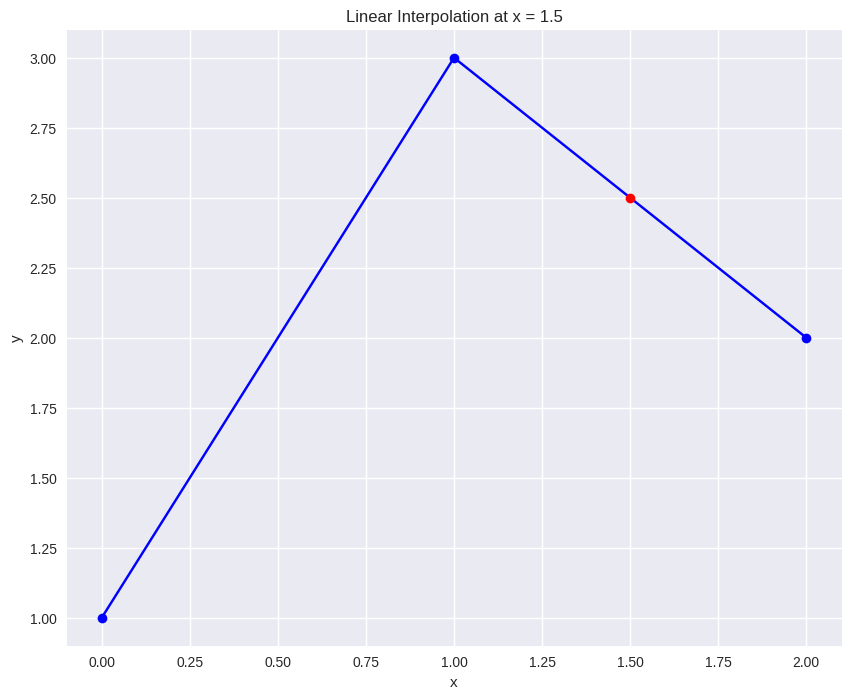

In [3]:
plt.figure(figsize = (10,8))
plt.plot(x, y, '-ob')
plt.plot(1.5, y_hat, 'ro')
plt.title('Linear Interpolation at x = 1.5')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

**Cubic Spline Interpolation**

In **cubic spline** interpolation (as shown in the following figure), the interpolating function is a set of piecewise cubic functions. Specifically, we assume that the points $(x_i,y_i)$ and $(x_{i+1},y_{i+1})$ are joined by a cubic polynomial $S_i(x)=a_ix^3+b_ix^2+c_ix+d_i$ that is valid for $x_i<x<x_{i+1}$ for $i=1,\dots,n-1$. To find the interpolating function, we must first determine the coefficients $a_i,b_i,c_i,d_i$ for each of the cubic functions. For $n$ points, there are $n-1$ cubic functions to find, and each cubic function requires four coefficients. Therefore we have a total of $4(n-1)$ unknowns, and so we need $4(n-1)$ independent equations to find all the coefficients.

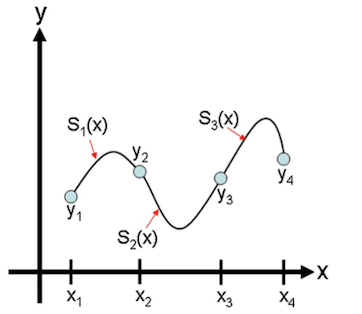

First we know that the cubic functions must intersect the data points on the left and the right:
$$S_i(x_i)=y_i,\quad i=1,2,\dots,n-1$$
$$S_i(x_{i+1})=y_{i+1},\quad i=1,2,\dots,n-1$$
which gives us $2(n-1)$ equations. Next, we want each cubic function to join as smoothly with its neighbors as possible, so we constrain the splines to have continuous first and second derivatives at the data points $i=2,\dots,n-1$.
$$S^{\prime}_i(x_{i+1})=S^{\prime}_{i+1}(x_{i+1}),\quad i=1,2,\dots,n-2$$
$$S^{\prime\prime}_i(x_{i+1})=S^{\prime\prime}_{i+1}(x_{i+1}),\quad i=1,2,\dots,n-2$$
which gives us $2(n-2)$ equations.

Two more equations are required to compute the coefficients of $S_i(x)$. These last two constraints are arbitrary, and they can be chosen to fit the circumstances of the interpolation being performed. A common set of final constraints is to assume that the second derivatives are zero at the endpoints. This means that the curve is a “straight line” at the end points. Explicitly,
$$S^{\prime\prime}_1(x_{1})=0$$
$$S^{\prime\prime}_{n-1}(x_{n})=0$$

In Python, we can use scipy's function $\verb|CubicSpline|$ to perform cubic spline interpolation. Note that the above constraints are not the same as the ones used by scipy's $\verb|CubicSpline|$ as default for performing cubic splines, there are different ways to add the final two constraints in scipy by setting the $\verb|bc_type|$ argument (see the help for $\verb|CubicSpline|$ to learn more about this).



Use CubicSpline to plot the cubic spline interpolation of the data set $x = [0, 1, 2]$ and $y = [1, 3, 2]$ for $0\le x \le 2$.

In [4]:
from scipy.interpolate import CubicSpline
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')

In [5]:
x = [0, 1, 2]
y = [1, 3, 2]

# Using bc_type = 'natural' adds the constraints as we described above
f = CubicSpline(x, y, bc_type='natural')
x_new = np.linspace(0, 2, 100)
y_new = f(x_new)

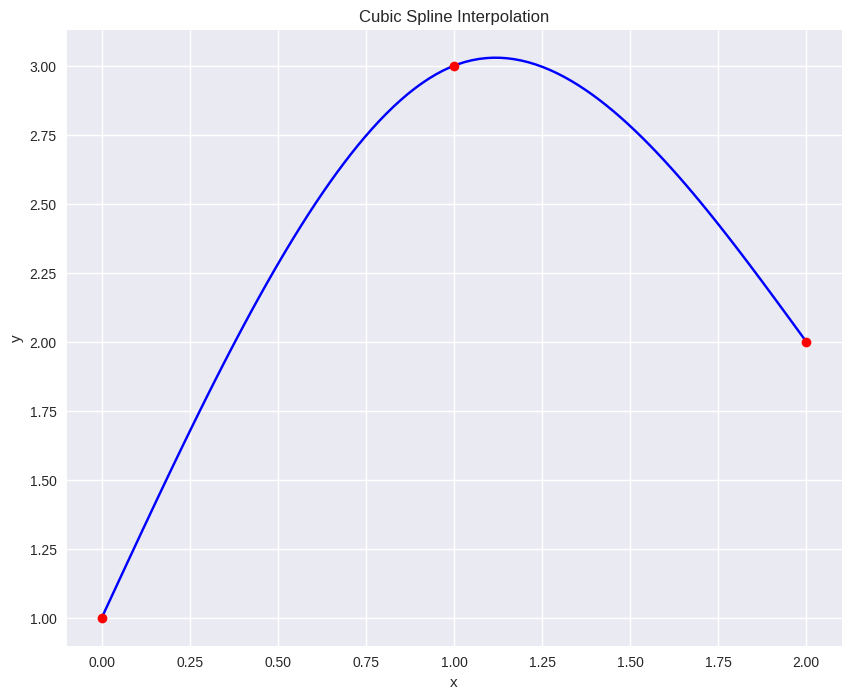

In [6]:
plt.figure(figsize = (10,8))
plt.plot(x_new, y_new, 'b')
plt.plot(x, y, 'ro')
#plt.plot(1.5, f(1.5), 'ko')
plt.title('Cubic Spline Interpolation')
plt.xlabel('x')
plt.ylabel('y')
#plt.grid()
plt.show()

To determine the coefficients of each cubic function, we write out the constraints explicitly as a system of linear equations with $4(n-1)$ unknowns. For $n$ data points, the unknowns are the coefficients $a_i,b_i,c_i,d_i$ of the cubic spline, $S_i$ joining the points $x_i$ and $x_{i+1}$.

For the constraints $S_i(x_i)=y_i$ we have:

$$\begin{cases}
a_1x_1^3 &+& b_1x_1^2 &+& c_1x_1^3&+& d_1=y_1\\
a_2x_2^3 &+& b_2x_2^2 &+&c_2x_2^3&+& d_2=y_2\\
&& & &\cdots&\\
a_{n-1}x_{n-1}^3 &+& b_{n-1}x_{n-1}^2 &+&c_{n-1}x_{n-1}^3&+& d_{n-1}=y_{n-1}\\
\end{cases}
$$
For the constraints $S_i(x_{i+1})=y_{i+1}$ we have:


$$\begin{cases}
a_1x_2^3 &+& b_1x_2^2 &+&c_1x_2^3&+& d_2=y_2\\
a_2x_3^3 &+& b_2x_3^2 &+&c_2x_3^3&+& d_2=y_3\\
&& & &\cdots&\\
a_{n-1}x_{n}^3 &+& b_{n-1}x_{n}^2 &+&c_{n-1}x_{n}^3&+& d_{n-1}=y_{n}\\
\end{cases}
$$

For the constraints $S^{\prime}_i(x_{i+1})=S^{\prime}_{i+1}(x_{i+1})$ we have:

$$\begin{cases}
3a_1x_2^2 &+& 2b_1x_2 &+& c_1 &-& 3a_2x_2^2&-& 2b_2x_2&-& c_2&=0\\
3a_2x_3^2 &+& 2b_2x_3 &+& c_2 &-& 3a_3x_3^2&-& 2b_3x_3&-&c_3&=0\\
&& & &\cdots&\\
3a_{n-2}x_{n-1}^2 &+& 2b_{n-2}x_{n-1} &+& c_{n-2} &-& 3a_{n-1}x_{n-1}^2&-& 2b_{n-1}x_{n-1}&-&c_{n-1}&=0\\
\end{cases}
$$
For the constraints $S^{\prime\prime}_i(x_{i+1})=S_{i+1}^{\prime\prime}(x_{i+1})$ we have:

$$\begin{cases}
6a_1x_2 &+& 2b_1 &-& 6a_2x_2&-& 2b_2&=0\\
6a_1x_3 &+& 2b_2 &-& 6a_3x_3&-& 2b_3&=0\\
&& & &\cdots&\\
6a_{n-2}x_{n-1} &+& 2b_{n-2} &-& 6a_{n-1}x_{n-1}&-& 2b_{n-1}&=0\\
\end{cases}
$$
Finally for the endpoint constraints $S^{\prime\prime}_{1}(x_1)=0$ and $S^{\prime\prime}_{n-1}(x_n)=0$, we have:
$$\begin{cases}
6a_1x_1 &+& 2b_1 &=0\\
6a_{n-1}x_{n} &+& 2b_{n-1}&=0\\
\end{cases}
$$

These equations are linear in the unknown coefficients $a_i,b_i,c_i$, and $d_i$. We can put them in matrix form and solve for the coefficients of each spline by left division. Remember that whenever we solve the matrix equation $Ax=b$ for $x$, we must make sure that $A$ is square and invertible. In the case of finding cubic spline equations, the $A$ matrix is always square and invertible as long as the $x_i$ values in the data set are unique.

Find the cubic spline interpolation at $x = 1.5$ based on the data $x = [0, 1, 2]$, $y = [1, 3, 2]$.

First we create the appropriate system of equations and find the coefficients of the cubic splines by solving the system in matrix form. The matrix form of the system of equations is:

$$
\begin{bmatrix}
0  & 0 & 0 &  1 & 0 & 0 & 0 & 0      \\
0  & 0 & 0 & 0  & 1 & 1 & 1 & 1      \\
1 & 1 & 1 & 1  & 0 & 0 & 0 & 0      \\   
0  & 0 & 0 &  0 & 8 & 4 & 2 & 1      \\
3  & 2 & 1 &  0 & -3 & -2 & -1 & 0      \\
6  & 2 & 0 &  0 & -6 & -2 & 0 & 0      \\
0  & 2 & 0 &  0 & 0 & 0 & 0 & 0      \\
0  & 0 & 0 &  0 & 12 & 2 & 0 & 0      \\
\end{bmatrix}
\begin{bmatrix}
a_1     \\
b_1     \\
c_1  \\
d_1    \\
a_2     \\
b_2     \\
c_2  \\
d_2    \\
\end{bmatrix}
    =
\begin{bmatrix}
1     \\
3     \\
3 \\
2\\
0     \\
0     \\
0 \\
0\\
\end{bmatrix}
$$

In [7]:
b = np.array([1, 3, 3, 2, 0, 0, 0, 0])
b = b[:, np.newaxis]
A = np.array([[0, 0, 0, 1, 0, 0, 0, 0], [0, 0, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 0, 0], \
             [0, 0, 0, 0, 8, 4, 2, 1], [3, 2, 1, 0, -3, -2, -1, 0], [6, 2, 0, 0, -6, -2, 0, 0],\
             [0, 2, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 12, 2, 0, 0]])

In [8]:
np.dot(np.linalg.inv(A), b)

array([[-0.75],
       [ 0.  ],
       [ 2.75],
       [ 1.  ],
       [ 0.75],
       [-4.5 ],
       [ 7.25],
       [-0.5 ]])

Therefore, the two cubic polynomials are

$$S_{1}(x)=-0.75x^3+2.75x+1,\; for\;0 \le x\le 1\; and$$
$$\hspace{.3in}S_{2}(x)=0.75x^3-4.5x^2+7.25x-0.5,\; for\; 1\le x \le 2 $$

So for $x=1.5$ we evaluate $S_2(1.5)$ and get an estimated value of $2.7813$.

**Lagrange Polynomial Interpolation**

Rather than finding cubic polynomials between subsequent pairs of data points, **Lagrange polynomial interpolation** finds a single polynomial that goes through all the data points. This polynomial is referred to as a **Lagrange polynomial**, $L(x)$, and as an interpolation function, it should have the property $L(x_i)=y_i$ for every point in the data set. For computing Lagrange polynomials, it is useful to write them as a linear combination of **Lagrange basis polynomials**, $P_i(x)$, where $P_i(x)=\prod_{j=1,j\ne i}^{n}\dfrac{x-x_j}{x_i-x_j}$ and $L(x)=\sum_{i=1}^{n}y_iP_i(x)$. Here, $\prod$ means "the product of" or "multiply out."

You will notice that by construction, $P_i(x)$ has the property that $P_i(x_k)=1$ when $i= k$ and $P_i(x_k)=0$ when $i\ne k$. Since $L(x)$ is a sum of these polynomials, you can observe that $L(x_i)=y_i$ for every point, exactly as desired.

Find the Lagrange basis polynomials for the data set $x = [0, 1, 2]$ and $y = [1, 3, 2]$. Plot each polynomial and verify the property that $P_i(x_k)=1$ when $i= k$ and $P_i(x_k)=0$ when $i\ne k$.

$$\hspace{.55in}P_1(x)=\dfrac{x-x_2}{x_1-x_2}\cdot\dfrac{x-x_3}{x_1-x_3}=\dfrac{x-1}{0-1}\cdot\dfrac{x-2}{0-3}=\frac{1}{2}\left(x^2-3x+2\right)$$
$$P_2(x)=\dfrac{x-x_1}{x_2-x_1}\cdot\dfrac{x-x_3}{x_2-x_3}=\dfrac{x-0}{1-0}\cdot\dfrac{x-2}{1-2}=-x^2+2x$$
$$P_3(x)=\dfrac{x-x_1}{x_3-x_1}\cdot\dfrac{x-x_2}{x_3-x_2}=\dfrac{x-0}{2-0}\cdot\dfrac{x-1}{2-1}=\frac{1}{2}\left(x^2-x\right)$$


In [9]:
import numpy as np
import numpy.polynomial.polynomial as poly
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')

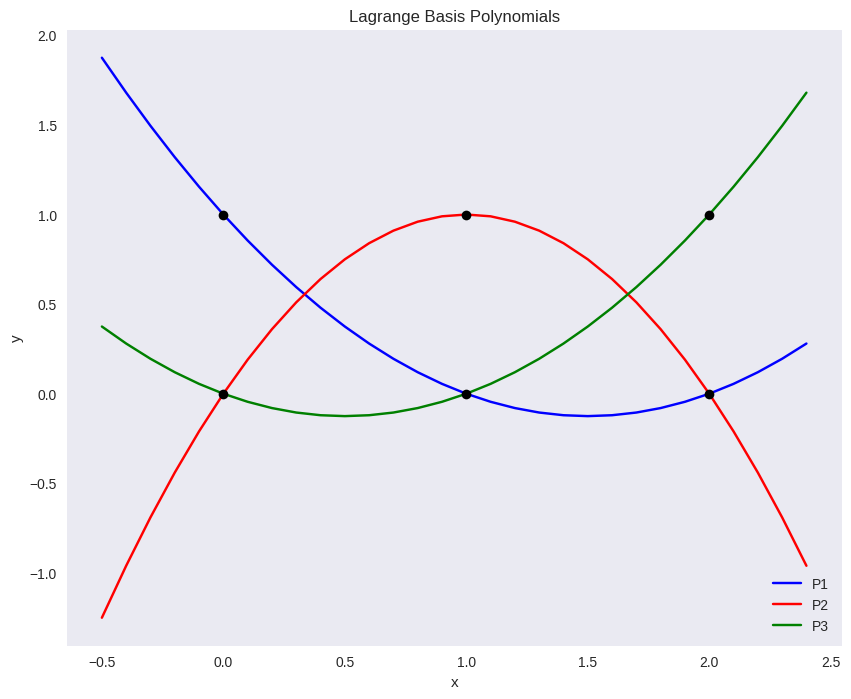

In [10]:
x = [0, 1, 2]
y = [1, 3, 2]
P1_coeff = [1,-1.5,.5] # [constant term, coef of x, coef of x^2]
P2_coeff = [0, 2,-1] # [constant term, coef of x, coef of x^2]
P3_coeff = [0,-.5,.5] # [constant term, coef of x, coef of x^2]

# get the polynomial function
P1 = poly.Polynomial(P1_coeff)
P2 = poly.Polynomial(P2_coeff)
P3 = poly.Polynomial(P3_coeff)

x_new = np.arange(-.5, 2.5, 0.1)

fig = plt.figure(figsize = (10,8))
plt.plot(x_new, P1(x_new), 'b', label = 'P1')
plt.plot(x_new, P2(x_new), 'r', label = 'P2')
plt.plot(x_new, P3(x_new), 'g', label = 'P3')


# plt.plot(x, np.ones(len(x)), 'ko')
# plt.plot(x, np.zeros(len(x)), 'ko')
# Same as the commented lines above
plt.plot(x, np.ones(len(x)), 'ko', x, np.zeros(len(x)), 'ko')

plt.title('Lagrange Basis Polynomials')
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.legend()
plt.show()

For the previous example, compute and plot the Lagrange polynomial and verify that it goes through each of the data points.

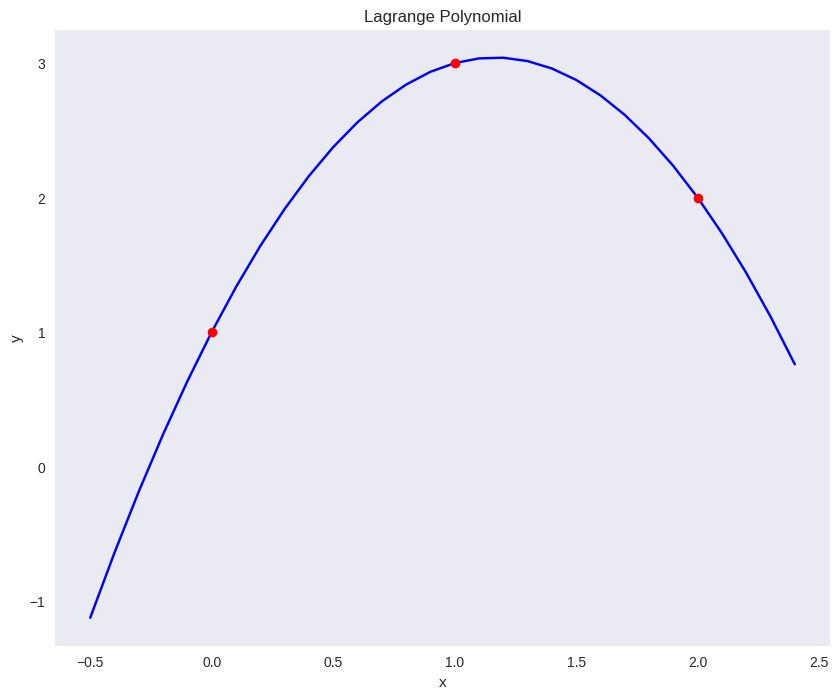

In [11]:
L = P1 + 3*P2 + 2*P3

fig = plt.figure(figsize = (10,8))
plt.plot(x_new, L(x_new),'b', x, y, 'ro')
plt.title('Lagrange Polynomial')
plt.grid()
plt.xlabel('x')
plt.ylabel('y')
plt.show()

**WARNING!** Lagrange interpolation polynomials are defined outside the area of interpolation, that is outside of the interval $[x_1,x_n]$, will grow very fast and unbounded outside this region. This is not a desirable feature because in general, this is not the behavior of the underlying data. Thus, a Lagrange interpolation should never be used to interpolate outside this region.



**Using lagrange from scipy**

Instead of calculating everything from scratch, in scipy, we can use the $\verb|lagrange|$ function directly to interpolate the data. Let's see the above example.

In [12]:
from scipy.interpolate import lagrange

In [13]:
f = lagrange(x, y)

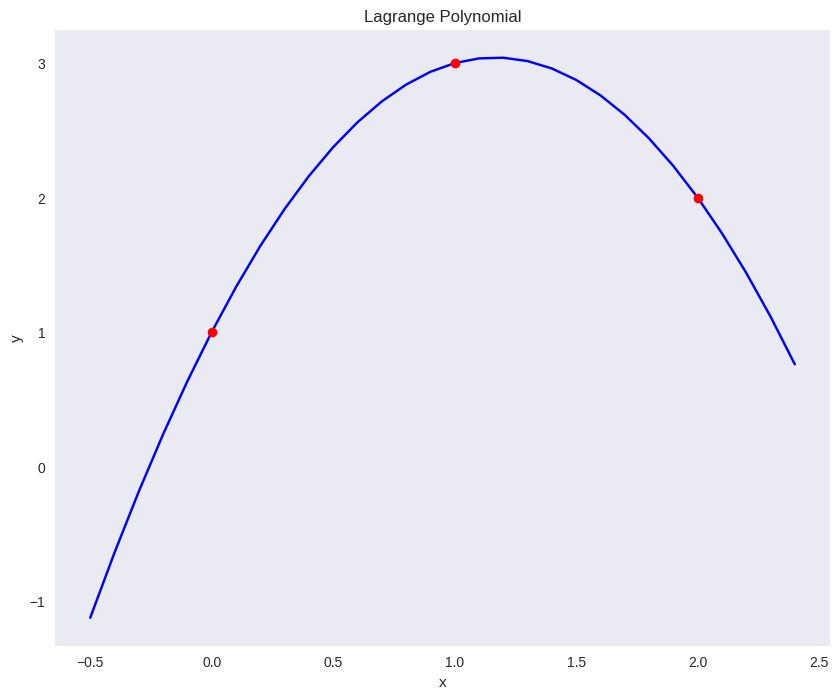

In [14]:
fig = plt.figure(figsize = (10,8))
plt.plot(x_new, f(x_new), 'b', x, y, 'ro')
plt.title('Lagrange Polynomial')
plt.grid()
plt.xlabel('x')
plt.ylabel('y')
plt.show()

**Newton's Polynomial Interpolation**

Newton's polynomial interpolation is another popular way to fit exactly for a set of data points. The general form of the $n$ order Newton's polynomial that goes through $n+1$ points is:
$$f(x)=a_0+a_1(x-x_0)+a_2(x-x_0)(x-x_1)+\dots+a_n(x-x_0)(x-x_1)\dots(x-x_{n-1}), \text{(the $x_k$ are assumed to be pairwise distinct)}$$
which can be re-written as:
$$f(x)=\sum_{i=0}^{n}a_in_i(x)$$
where $n_i(x)=\prod_{j=0}^{i-1}(x-x_j)$, for $i>0$ and $n_0(x)=1$.

The special feature of the Newton's polynomial is that the coefficients $a_i$ can be determined using a very simple mathematical procedure. For example, since the polynomial goes through each data points, therefore, for data points $(x_i,y_i)$, we will have $f(x_i)=y_i$, thus we have
$$f(x_0)=a_0=y_0$$
And $f(x_1)=a_0+a_1(x_1-x_0)=y_1$, by rearranging it to get $a_1$, we will have:
$$a_1=\dfrac{y_1-y_0}{x_1-x_0}$$

Now, insert data points $(x_2,y_2)$, we can calculate $a_2$, and it is in the form:
$$a_2=\dfrac{\dfrac{y_2-y_1}{x_2-x_1}-\dfrac{y_1-y_0}{x_1-x_0}}{x_2-x_0}$$
Let's do one more data points $(x_3,y_3)$ to calculate $a_3$, after insert the data point into the equation, we get:
$$a_3=\dfrac{\dfrac{\dfrac{y_3-y_2}{x_3-x_2}-\dfrac{y_2-y_1}{x_2-x_1}}{x_3-x_1}-\dfrac{\dfrac{y_2-y_1}{x_2-x_1}-\dfrac{y_1-y_0}{x_1-x_0}}{x_2-x_0}}{x_3-x_0}$$


Now, see the patterns? These are called **divided differences**, if we define:
$$f[x_1,x_0]=\dfrac{y_1-y_0}{x_1-x_0}$$
$$\hspace{.8in}f[x_2,x_1,x_0]=\dfrac{\dfrac{y_2-y_1}{x_2-x_1}-\dfrac{y_1-y_0}{x_1-x_0}}{x_2-x_0}=\dfrac{f[x_2,x_1]-f[x_1,x_0]}{x_2-x_0}$$
If we continue writing this out, we will have the following iteration equation:
$$\hspace{.8in}f[x_k,x_{k-1},\dots,x_1,x_0]=\dfrac{f[x_k,x_{k-1},\dots,x_2,x_1]-f[x_{k-1},\dots,x_1,x_0]}{x_k-x_0}$$
We can see one beauty of the method is that, once the coefficients are determined, adding new data points won't change the calculated ones, we only need to calculate higher differences that continues in the same manner. Let's see an example using 5 data points. We can calculate each element and store them into a matrix, that is the coefficients matrix can be written as:
$$\begin{bmatrix}
y_0       &   f[x_1,x_0]       & f[x_2,x_1,x_0]     &   f[x_3,x_2,x_1,x_0]  & f[x_4,x_3,x_2,x_1,x_0]  \\
y_1       &   f[x_2,x_1]       & f[x_3,x_2,x_1]     &   f[x_4,x_3,x_2,x_1]  & 0 \\
y_2       &   f[x_3,x_2]       & f[x_4,x_3,x_2]     &   0  & 0 \\
y_2       &   f[x_4,x_3]       & 0   &   0  & 0 \\
y_4       &   0        & 0    &   0   &0    \\
\end{bmatrix}$$
Note that, the first row in the matrix is actually all the coefficients that we need, i.e. $a_0,a_1,a_2,a_3,a_4$. Let's see an example.

Calculate the divided differences table for $x = [-5, -1, 0, 2]$, $y = [-2, 6, 1, 3]$.

In [15]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')

In [16]:
def divided_diff(x, y):
  '''
  function to calculate the divided
  differences table
  '''
  n = len(y)
  coef = np.zeros((n, n))
  # the first column is y
  coef[:,0] = y

  for j in range(1,n):
    for i in range(n-j):
      coef[i][j] = \
          (coef[i+1][j-1] - coef[i][j-1]) / (x[i+j]-x[i])

  return coef

In [17]:
def newton_poly_1(coeff, x_data, x): # coeff here are the a_i's.
    '''
    evaluate the newton polynomial
    at x
    '''
    n = len(x_data)
    p = coeff[0]
    prod = 1
    for k in range(n-1):
      prod = (x -x_data[k])*prod
      p = p + coeff[k+1]*prod
    return p

In [18]:
# Different way of constructing newton poly function
def newton_poly_2(coeff, x_data, x): # coeff here are the a_i's.

    '''
    evaluate the newton polynomial
    at x
    '''
    n = len(x_data) - 1
    p = coeff[n]
    for k in range(1,n+1):
        p = coeff[n-k] + (x -x_data[n-k])*p
    return p

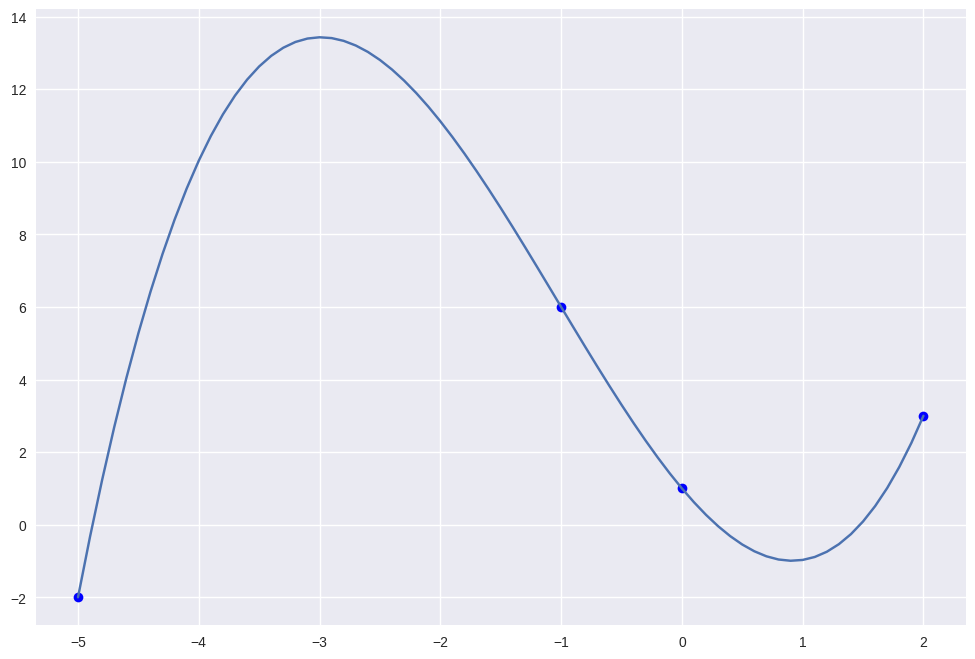

In [19]:
x = np.array([-5, -1, 0, 2])
y = np.array([-2, 6, 1, 3])
# get the divided difference coef
a_s = divided_diff(x, y)[0, :]

# evaluate on new data points
x_new = np.arange(-5, 2.1, .1)
y_new = newton_poly_1(a_s, x, x_new)

plt.figure(figsize = (12, 8))
plt.plot(x, y, 'bo')
plt.plot(x_new, y_new)

We can see that the Newton's polynomial goes through all the data points and fit the data.